# 01 - Data Exploration

Inspect the bundled seed data (historical international results, team metadata, and the 2026 group draw). The match results are synthetic but follow a realistic strength hierarchy so the models have something meaningful to learn. Swap in a real dataset to get real-world predictions.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config
from wcpredictor.data import load_matches, load_teams, load_groups
from wcpredictor.data.preprocess import build_training_matches, team_match_counts

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)


Matplotlib is building the font cache; this may take a moment.


In [2]:
matches = load_matches(config)
teams = load_teams(config)
groups = load_groups(config)
print('matches:', matches.shape)
print('teams:', teams.shape)
print('date range:', matches['date'].min().date(), '->', matches['date'].max().date())
matches.head()

matches: (1320, 7)
teams: (48, 3)
date range: 2022-01-01 -> 2026-04-30


,date,home_team,away_team,home_score,away_score,neutral,tournament
0,2022-01-01,New Zealand,Portugal,2,1,False,Continental Cup
1,2022-01-01,Spain,Ecuador,2,0,True,Friendly
2,2022-01-03,Austria,Switzerland,1,1,False,Friendly
3,2022-01-06,Panama,Denmark,0,3,False,Continental Cup
4,2022-01-06,Germany,Serbia,1,1,False,Qualifier


## Match outcomes (home / draw / away)

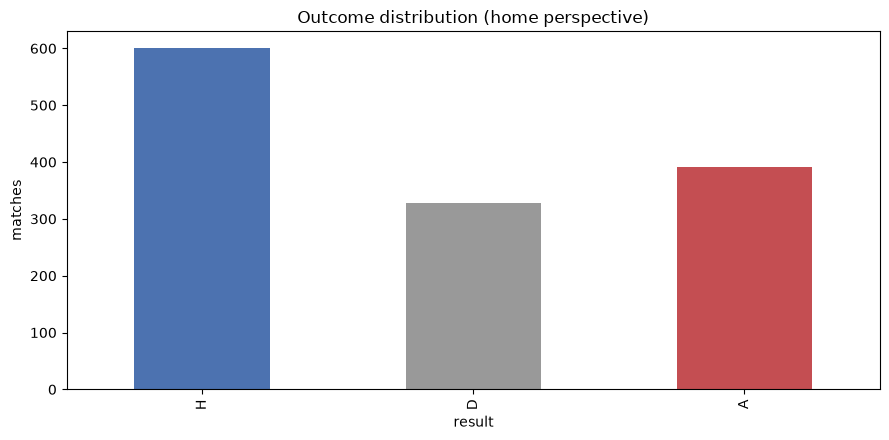

result
H    600
D    328
A    392
Name: count, dtype: int64

In [3]:
tr = build_training_matches(matches, config)
counts = tr['result'].value_counts().reindex(['H', 'D', 'A'])
ax = counts.plot.bar(color=['#4C72B0', '#999999', '#C44E52'])
ax.set_title('Outcome distribution (home perspective)')
ax.set_xlabel('result'); ax.set_ylabel('matches')
plt.tight_layout(); plt.show()
counts

## Goals per match

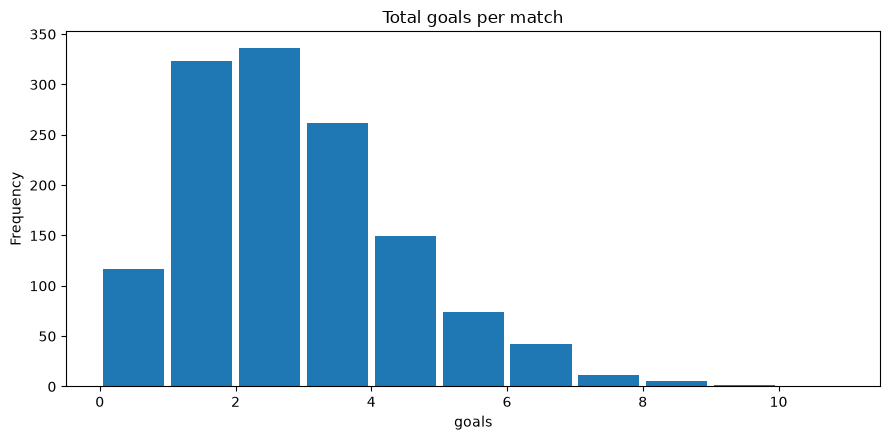

mean goals/match: 2.37


In [4]:
ax = tr['total_goals'].plot.hist(bins=range(0, 12), rwidth=0.9)
ax.set_title('Total goals per match')
ax.set_xlabel('goals'); plt.tight_layout(); plt.show()
print('mean goals/match:', round(tr['total_goals'].mean(), 2))

## Matches played per team and the group draw

In [5]:
display(team_match_counts(matches).head(10).to_frame('matches'))
groups.groupby('group')['team'].apply(list)

,matches
home_team,
Australia,73
Cameroon,73
Senegal,68
Netherlands,67
Norway,65
Paraguay,65
Tunisia,65
Algeria,63
Croatia,63


group
A     [Germany, South Korea, Mexico, Paraguay]
B           [Uruguay, Denmark, Egypt, Jamaica]
C    [Spain, Colombia, Scotland, Saudi Arabia]
D           [Italy, Ivory Coast, Ecuador, USA]
E      [England, Senegal, Hungary, Costa Rica]
F             [Morocco, Japan, Serbia, Panama]
G          [Portugal, Nigeria, Ukraine, Qatar]
H       [Brazil, Algeria, Poland, New Zealand]
I     [France, Switzerland, Ghana, Uzbekistan]
J          [Netherlands, Norway, Iran, Canada]
K           [Belgium, Austria, Cameroon, Iraq]
L     [Argentina, Croatia, Australia, Tunisia]
Name: team, dtype: object